Robustness Checks:
- Compare our long underperformer with a long overperformer portfolio (as a benchmark)
- We should see a volume uptick in the last 7 days as an underperformer as compared to when its an overperformer
- Check different time frames (it should work as well)
- Check for different indexes (check if it works for IWV vs AGG etc...)

In [72]:
import yfinance as yf
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple
import itertools

In [73]:
# Calc sharpe ratio 
def sharpe_ratio(series, trading_days=252):
    mean = series.mean()
    std = series.std()
    return (mean / std) * np.sqrt(trading_days) if std > 0 else np.nan

In [74]:
def getSignal(tickers, lookback_days=15, trade_window_days=7, start="2002-07-30", end=None):
    """
    Monthly rebalance signal:
      - look back `lookback_days` from start of month to pick underperformer
      - trade underperformer for last `trade_window_days` of month
    """
    # --- download data ---
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"].dropna()
    df = pl.from_pandas(data.reset_index()).rename({"Date": "date"}).sort("date")

    # --- compute returns ---
    for t in tickers:
        df = df.with_columns((pl.col(t) / pl.col(t).shift(1) - 1).alias(f"r_{t}"))
    df = df.drop_nulls()

    # --- add year/month ---
    grouped = df.with_columns([
        pl.col("date").dt.year().alias("year"),
        pl.col("date").dt.month().alias("month"),
    ])

    trades = []
    for (yr, mo), g in grouped.group_by(["year", "month"], maintain_order=True):
        g = g.sort("date")
        if g.height < lookback_days:
            continue

        # performance in first lookback_days
        perf = {t: g[f"r_{t}"][:lookback_days].log1p().sum() for t in tickers}
        under = min(perf, key=perf.get)   # underperformer
        over  = max(perf, key=perf.get)   # overperformer

        # last trade_window_days of month
        trade = g.slice(lookback_days, g.height - lookback_days)
        if trade.is_empty():
            continue

        lo_under = trade[f"r_{under}"]
        lo_over  = trade[f"r_{over}"]

        trades.append(pl.DataFrame({
            "date": trade["date"],
            "r_lo_under": lo_under,
            "r_lo_over":  lo_over,
        }))

    # --- combine trades ---
    strat = pl.concat(trades) if trades else pl.DataFrame({"date": []})

    # --- merge with base to keep benchmarks ---
    merged = (
        grouped.select(["date"] + [f"r_{t}" for t in tickers])
        .join(strat, on="date", how="left")
        .fill_null(0.0)
    )

    # --- cumulative log returns ---
    for c in [f"r_{t}" for t in tickers] + ["r_lo_under", "r_lo_over"]:
        merged = merged.with_columns((pl.col(c).log1p().cum_sum()).alias(f"cum_{c}"))

    return merged

### Comparison Portfolio

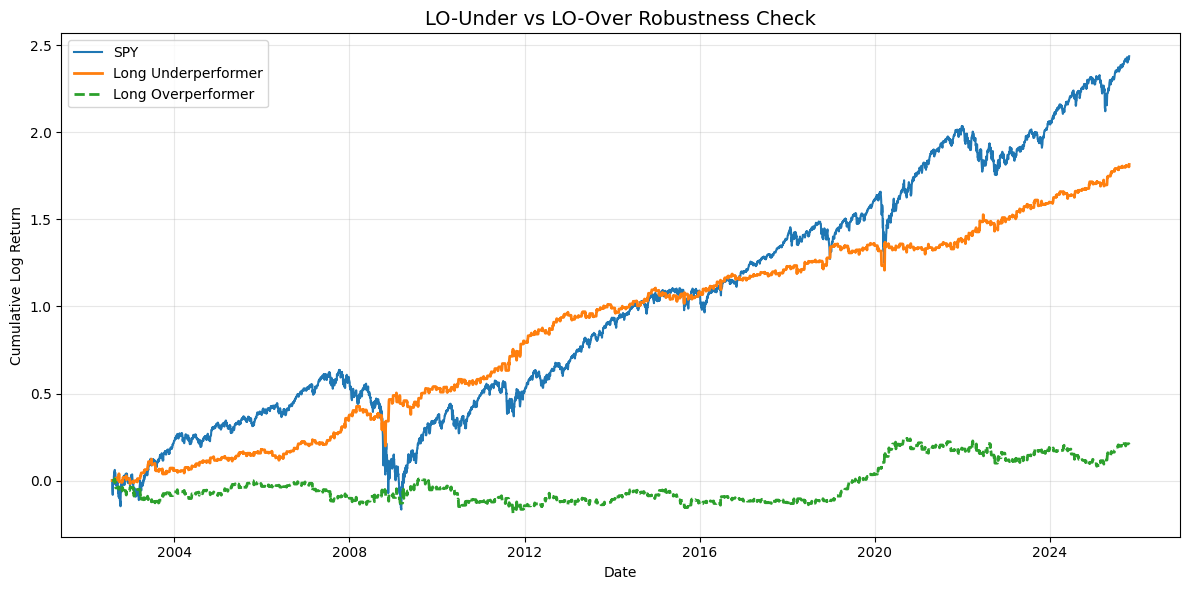

In [75]:
tickers = ["SPY", "TLT"]
sig = getSignal(tickers, lookback_days=15, trade_window_days=7)

plt.figure(figsize=(12,6))
    
plt.plot(sig["date"], sig["cum_r_SPY"],        label="SPY", linewidth=1.5)
plt.plot(sig["date"], sig["cum_r_lo_under"],   label="Long Underperformer", linewidth=2)
plt.plot(sig["date"], sig["cum_r_lo_over"],    label="Long Overperformer", linewidth=2, linestyle="--")
    
plt.title("LO-Under vs LO-Over Robustness Check", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
# Calc sharpe ratio
sharpe = {
    "SPY": round(sharpe_ratio(sig["r_SPY"].to_numpy()), 3),
    "TLT": round(sharpe_ratio(sig["r_TLT"].to_numpy()), 3),
    "Long-Only Underperformer": round(sharpe_ratio(sig["r_lo_under"].fill_null(0).to_numpy()), 3),
    "Long-Only Overperformer": round(sharpe_ratio(sig["r_lo_over"].fill_null(0).to_numpy()), 3),
}

sharpe

{'SPY': np.float64(0.649),
 'TLT': np.float64(0.342),
 'Long-Only Underperformer': np.float64(0.895),
 'Long-Only Overperformer': np.float64(0.154)}

### Different Time Frame

In [77]:
def run_shifted_windows(
    tickers=("SPY", "TLT"),
    start="2002-07-30",
    end=None,
    total_days=22  # typical month length
):
    results = {}

    # From (15,7) down to (7,15)
    for lookback in range(15, 6, -1):
        trade_window = total_days - lookback
        label = f"L{lookback}_T{trade_window}"
        sig = getSignal(tickers, lookback_days=lookback,
                        trade_window_days=trade_window,
                        start=start, end=end)
        results[label] = sig

    # From (16,6) up to (19,3)
    for lookback in range(16, 20):
        trade_window = total_days - lookback
        label = f"L{lookback}_T{trade_window}"
        sig = getSignal(tickers, lookback_days=lookback,
                        trade_window_days=trade_window,
                        start=start, end=end)
        results[label] = sig

    return results


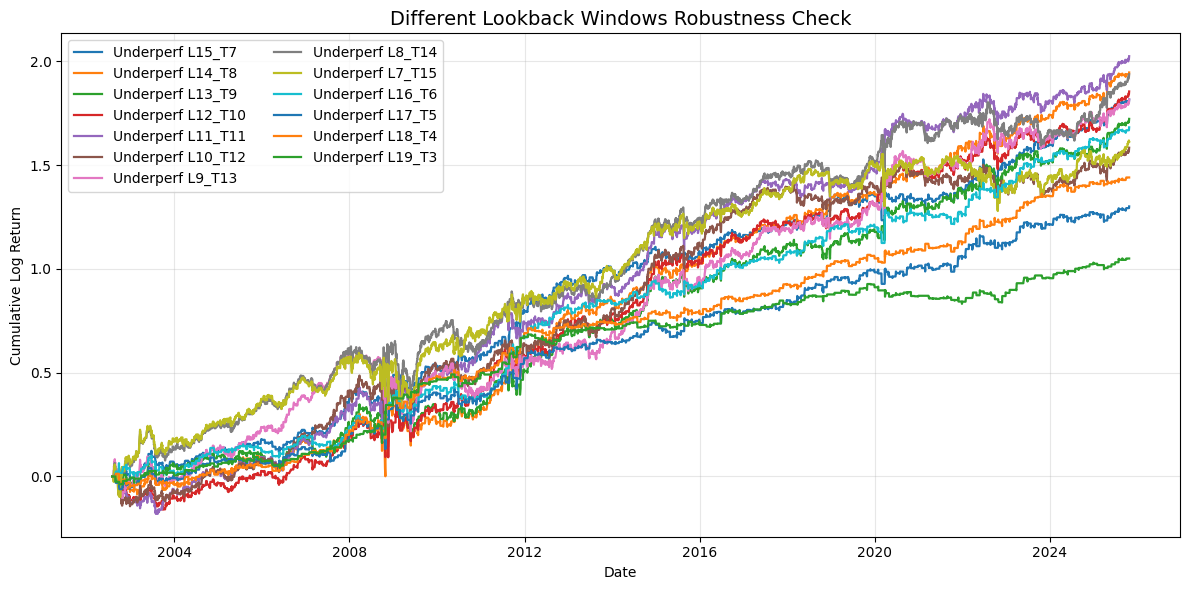

In [78]:
def plot_shifted_results(results):
    plt.figure(figsize=(12,6))

    # plot each shifted window
    for label, sig in results.items():
        plt.plot(sig["date"], sig["cum_r_lo_under"],
                 label=f"Underperf {label}", linewidth=1.6)

    plt.title("Different Lookback Windows Robustness Check", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()
    
results = run_shifted_windows(("SPY", "TLT"))
plot_shifted_results(results)

The above plot shows that the signal works even when you move the lookback period around between 7 days all the way till 19 days of lookback

### Different Index Check

In [79]:
equity_tickers = [
    "SPY",  # S&P 500
    "VOO",  # S&P 500 (Vanguard)
    "IVV",  # S&P 500 (iShares)
    "IWV",  # Russell 3000
    "IWM",  # Russell 2000 (small caps)
    "VTI",  # Total US Market
    "QQQ",  # Nasdaq 100
    "DIA",  # Dow Jones
]

bond_tickers = [
    "TLT",  # 20+ Year Treasuries
    "IEF",  # 7–10 Year Treasuries
    "SHY",  # 1–3 Year Treasuries
    "AGG",  # US Aggregate
    "LQD",  # Investment Grade Corporate
    "GOVT", # All Treasury maturities
    "TIP",  # Inflation-Protected Treasuries
    "TLH",  # 10–20 Year Treasuries
]

In [80]:
all_pairs = list(itertools.product(equity_tickers, bond_tickers))
results_all = {}

for eq, bd in all_pairs:
    label = f"{eq}/{bd}"
    try:
        sig = getSignal((eq, bd), lookback_days=15, trade_window_days=7)
        results_all[label] = sig
    except Exception as e:
        print(f"{label} FAILKED")

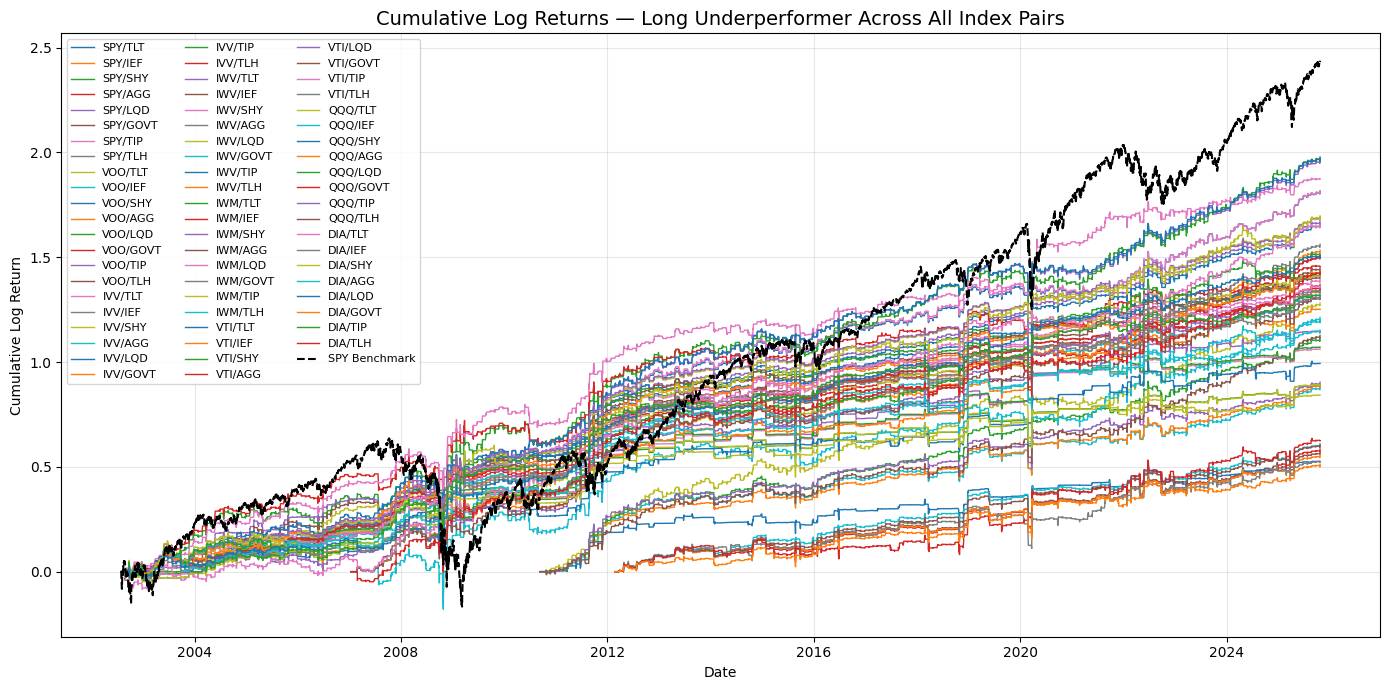

In [81]:
def plot_all_pairs(results_all, show_benchmark=False, benchmark="SPY"):
    """
    Plot cumulative log returns of the Long-Underperformer strategy (r_lo_under)
    for every (equity, bond) pair stored in results_all.
    """
    plt.figure(figsize=(14, 7))

    for label, sig in results_all.items():
        plt.plot(sig["date"], sig["cum_r_lo_under"], label=label, linewidth=1)

    if show_benchmark:
        first_sig = next(iter(results_all.values()))
        plt.plot(first_sig["date"], first_sig[f"cum_r_{benchmark}"],
                 color="black", linewidth=1.5, linestyle="--", label=f"{benchmark} Benchmark")

    plt.title("Cumulative Log Returns — Long Underperformer Across All Index Pairs", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()
    
plot_all_pairs(results_all, show_benchmark=True)

While the above graph is VERY messy, the lines go up and to the right showing that this signal is agnostic to what indices you use (of course some indices will work better)

### Volume Check

In [82]:
def get_daily_volume_profile(tickers=("SPY","TLT"), start="2002-07-30", end=None):
    """
    For each month, identify which ticker under/over-performed in first 15 trading days.
    Then compute average volume by day-in-month for each role (under/over) and each ticker.
    """
    # Download data
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)[["Close","Volume"]].dropna()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [f"{a}_{b}" for a,b in data.columns]

    df = pl.from_pandas(data.reset_index()).rename({"Date":"date"}).sort("date")

    # Compute returns
    for t in tickers:
        df = df.with_columns((pl.col(f"Close_{t}")/pl.col(f"Close_{t}").shift(1)-1).alias(f"r_{t}"))
    df = df.drop_nulls()

    # Add year/month and day_in_month
    df = df.with_columns([
        pl.col("date").dt.year().alias("year"),
        pl.col("date").dt.month().alias("month"),
    ])
    
    # Create records per month
    records = []
    for (yr,mo), g in df.group_by(["year","month"], maintain_order=True):
        g = g.sort("date").with_columns(pl.arange(1, g.height+1).alias("day_in_month"))
        if g.height < 15:
            continue

        # Determine under/over in first 15 trading days
        ret_15 = {t: g[f"r_{t}"][:15].log1p().sum() for t in tickers}
        under = min(ret_15, key=ret_15.get)
        over  = max(ret_15, key=ret_15.get)

        # Label volume for each ticker
        for t in tickers:
            role = "under" if t == under else "over"
            records.append(
                g.select(["year","month","day_in_month",pl.col(f"Volume_{t}").alias("volume")])
                 .with_columns(pl.lit(t).alias("ticker"), pl.lit(role).alias("role"))
            )

    full = pl.concat(records)
    return full


def plot_volume_profiles(full, ticker):
    """Plot average daily volume profile (by day_in_month) for a given ticker."""
    df = full.filter(pl.col("ticker") == ticker)

    # Average per day_in_month by role
    avg_norm = df.group_by("day_in_month").agg(pl.col("volume").mean().alias("avg_vol")).sort("day_in_month")
    avg_under = df.filter(pl.col("role")=="under").group_by("day_in_month").agg(pl.col("volume").mean().alias("avg_vol")).sort("day_in_month")
    avg_over  = df.filter(pl.col("role")=="over").group_by("day_in_month").agg(pl.col("volume").mean().alias("avg_vol")).sort("day_in_month")

    plt.figure(figsize=(10,5))
    plt.plot(avg_norm["day_in_month"], avg_norm["avg_vol"], color="gray", label="All Months", linewidth=1.5)
    plt.plot(avg_under["day_in_month"], avg_under["avg_vol"], color="orange", label="Underperformer Months", linewidth=2)
    plt.plot(avg_over["day_in_month"], avg_over["avg_vol"], color="skyblue", label="Overperformer Months", linewidth=2, linestyle="--")
    plt.title(f"Average Daily Volume Profile — {ticker}", fontsize=14)
    plt.xlabel("Trading Day of Month")
    plt.ylabel("Average Volume")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

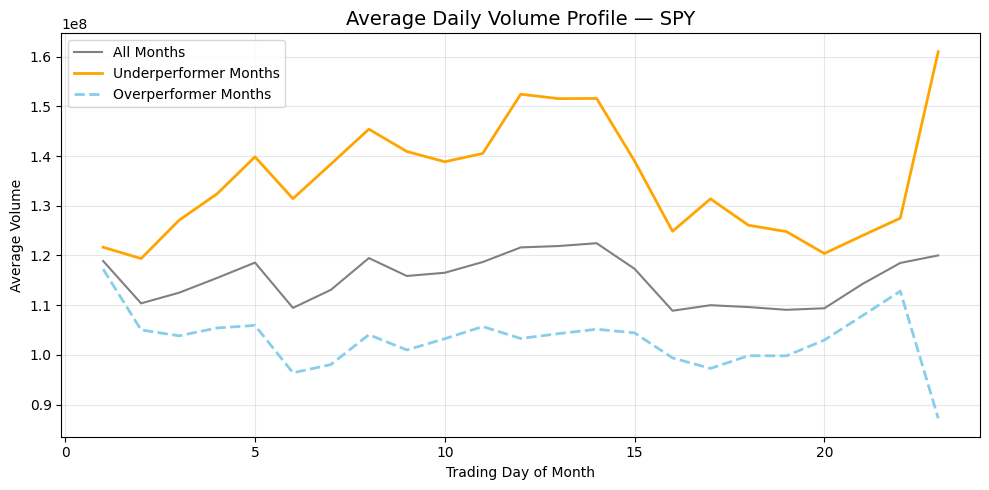

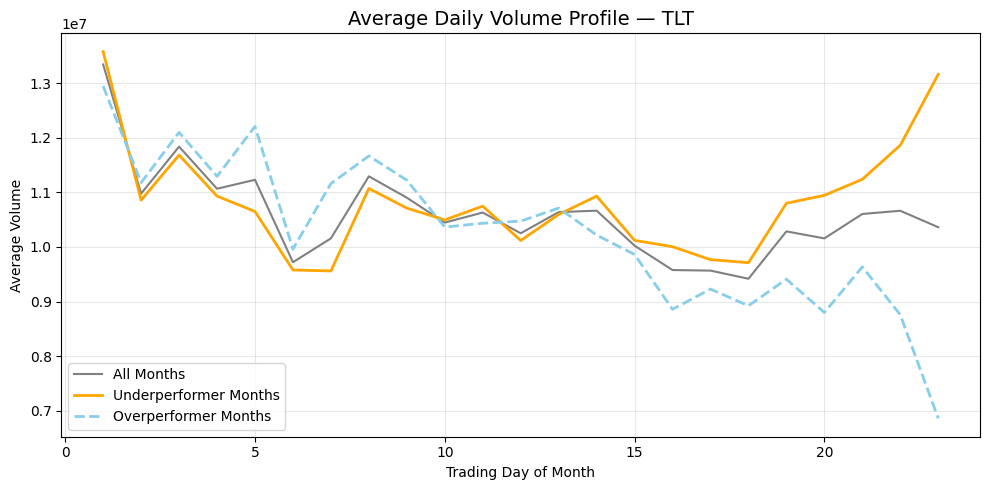

In [83]:
full_vol = get_daily_volume_profile(("SPY","TLT"))

plot_volume_profiles(full_vol, "SPY")
plot_volume_profiles(full_vol, "TLT")